# DroneTwin Minimal End-to-End Demo

This notebook demonstrates a complete geometry-based 3D perception workflow for an aerial mapping dataset. It starts from overlapping imagery / COLMAP reconstruction output, cleans the dense point cloud, measures the scene, separates ground from elevated structure, grows surface regions, and assigns coarse semantic classes.

The default path starts from an existing COLMAP dense fusion output because full photogrammetry can take a long time. Set `REBUILD_COLMAP = True` below if you want to rebuild from `data/raw` first.

The notebook calls popup-capable scripts with `--no-view` and renders lightweight sampled results inline under each cell.

## Demo Scope

This notebook is a compact technical record of the pipeline stages and the artifacts each stage produces.

- **Photogrammetry:** raw drone imagery is converted into dense 3D geometry with COLMAP.
- **Point-cloud engineering:** noisy reconstruction output is filtered and downsampled into a usable working cloud.
- **Geometry-based segmentation:** RANSAC, local surface normals, region growing, and rule-based scoring create inspectable labels.
- **Explainability:** every stage writes artifacts and prints counts, dimensions, thresholds, and class summaries so the result can be debugged visually and numerically.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
import pandas as pd
from IPython.display import display


def find_project_root() -> Path:
    """Find the repo root whether the notebook starts in / or /scripts."""
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "README.md").exists() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError("Could not find DroneTwin project root")


PROJECT_ROOT = find_project_root()
DENSE_DIR = PROJECT_ROOT / "data" / "processed" / "dense"
PYTHON = sys.executable
MAX_INLINE_POINTS = 80_000


def run_script(label: str, script: str, *args: str) -> subprocess.CompletedProcess[str]:
    """Run one repo script from the project root and print its output."""
    command = [PYTHON, str(PROJECT_ROOT / script), *map(str, args)]
    print(f"\n=== {label} ===")
    print(" ".join(command))
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    if result.stdout:
        print(result.stdout)
    result.check_returncode()
    return result


def require_outputs(*paths: Path) -> None:
    missing = [path for path in paths if not path.exists()]
    if missing:
        missing_text = "\n".join(str(path) for path in missing)
        raise FileNotFoundError(f"Missing expected output(s):\n{missing_text}")
    for path in paths:
        print(f"ok: {path.relative_to(PROJECT_ROOT)}")


def sampled_cloud(path: Path, max_points: int = MAX_INLINE_POINTS):
    """Load a PLY and return a deterministic sample for inline plotting."""
    cloud = o3d.io.read_point_cloud(str(path))
    if cloud.is_empty():
        raise ValueError(f"No points loaded from {path}")
    points = np.asarray(cloud.points)
    colors = np.asarray(cloud.colors) if cloud.has_colors() else None
    if len(points) > max_points:
        rng = np.random.default_rng(7)
        indices = np.sort(rng.choice(len(points), size=max_points, replace=False))
        points = points[indices]
        if colors is not None:
            colors = colors[indices]
    return points, colors


def show_cloud(path: Path, title: str, max_points: int = MAX_INLINE_POINTS) -> None:
    """Show a static sampled 3D cloud inline under the notebook cell."""
    points, colors = sampled_cloud(path, max_points=max_points)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    marker_colors = colors if colors is not None and len(colors) == len(points) else points[:, 2]
    scatter = ax.scatter(
        points[:, 0],
        points[:, 1],
        points[:, 2],
        c=marker_colors,
        s=0.35,
        linewidths=0,
        cmap=None if colors is not None else "viridis",
    )
    if colors is None:
        fig.colorbar(scatter, ax=ax, shrink=0.6, label="Z")
    ax.set_title(f"{title} ({len(points):,} sampled points)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    extent = np.ptp(points, axis=0)
    ax.set_box_aspect(np.maximum(extent, 1e-9))
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    plt.show()


def show_class_report(path: Path, rows: int = 12) -> None:
    """Display the semantic classification CSV inline."""
    report = pd.read_csv(path)
    if "class_name" in report.columns:
        counts = report["class_name"].value_counts().rename_axis("class_name").reset_index(name="region_count")
        display(counts)
    display(report.head(rows))


print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {PYTHON}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Project root: C:\Users\jrwhite\Documents\Proj\DroneTwin
Python: c:\Users\jrwhite\AppData\Local\miniconda3\envs\drone-twin\python.exe


## Configuration

`REBUILD_COLMAP` is off by default so the demo can use the dense point cloud already generated by `run_colmap.py`. Turn it on only when you want to rerun photogrammetry from the raw image folder.

In [2]:
REBUILD_COLMAP = False
CLEAN_COLMAP_OUTPUTS = False
VIEW_SEMANTIC_CLASSES = False

RAW_FUSED = DENSE_DIR / "fused-keep-more.ply"
CLEANED = DENSE_DIR / "fused-keep-more-cleaned.ply"
GROUND = DENSE_DIR / "ground.ply"
NON_GROUND = DENSE_DIR / "non_ground.ply"
REGIONS = DENSE_DIR / "non_ground_regions.ply"
REGION_PROXY = DENSE_DIR / "non_ground_regions_proxy.ply"
REGION_LABELS = DENSE_DIR / "non_ground_region_labels.npz"
SEMANTIC = DENSE_DIR / "semantic_classes.ply"
NON_GROUND_SEMANTIC = DENSE_DIR / "non_ground_semantic_classes.ply"
REPORT = DENSE_DIR / "region_class_report.csv"
LEGEND = DENSE_DIR / "semantic_class_legend.csv"

## 1. Photogrammetry: `run_colmap.py`

COLMAP turns overlapping drone images into sparse/dense reconstruction products. The later Open3D scripts use `data/processed/dense/fused-keep-more.ply`.

In [3]:
if REBUILD_COLMAP:
    colmap_args = ["--clean"] if CLEAN_COLMAP_OUTPUTS else []
    run_script("COLMAP reconstruction", "scripts/run_colmap.py", *colmap_args)
else:
    print("Skipping COLMAP rebuild. Set REBUILD_COLMAP = True to run scripts/run_colmap.py.")

require_outputs(RAW_FUSED)

Skipping COLMAP rebuild. Set REBUILD_COLMAP = True to run scripts/run_colmap.py.
ok: data\processed\dense\fused-keep-more.ply


## 2. Cleanup: `clean_point_cloud.py`

This removes isolated points and downsamples the dense fusion into a cleaner working cloud.

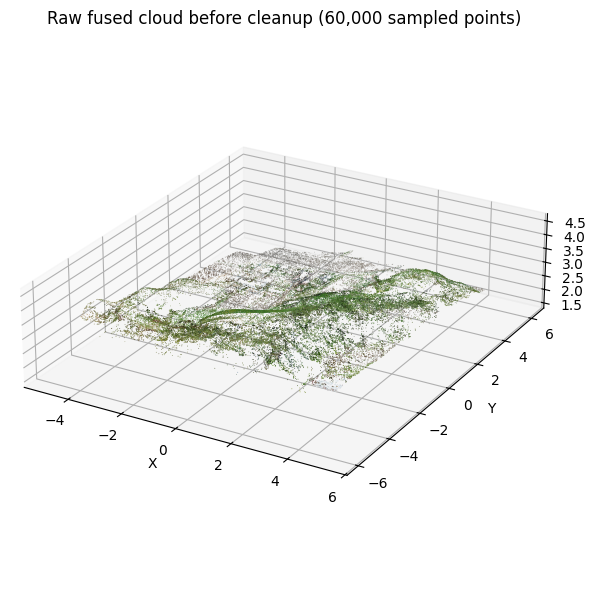


=== Clean dense point cloud ===
c:\Users\jrwhite\AppData\Local\miniconda3\envs\drone-twin\python.exe C:\Users\jrwhite\Documents\Proj\DroneTwin\scripts\clean_point_cloud.py


Loaded: 15,377,970 points | min=(-8.439, -5.997, 1.304) | max=(6.822, 6.357, 15.424)
Statistical outlier removal kept 15,300,981 points
After statistical filter: 15,300,981 points | min=(-4.938, -5.853, 1.489) | max=(5.359, 6.097, 3.849)
Voxel downsampling with voxel size 0.015950
After voxel downsample: 886,300 points | min=(-4.934, -5.850, 1.495) | max=(5.359, 6.093, 3.846)
Wrote C:\Users\jrwhite\Documents\Proj\DroneTwin\data\processed\dense\fused-keep-more-cleaned.ply

ok: data\processed\dense\fused-keep-more-cleaned.ply


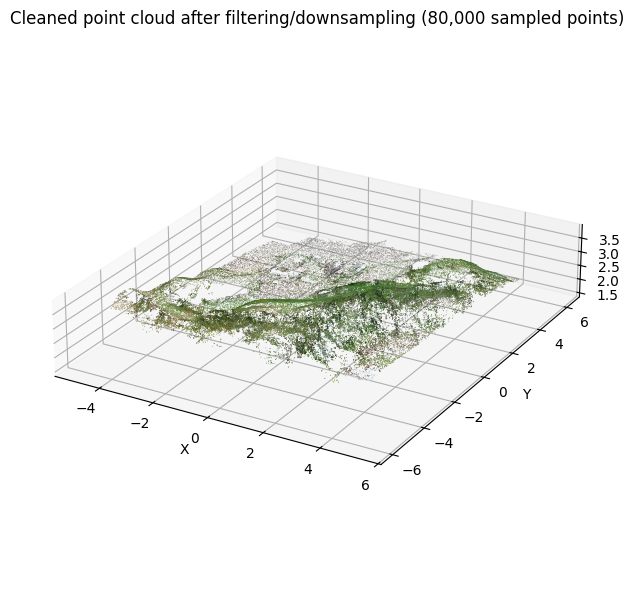

In [4]:
show_cloud(RAW_FUSED, "Raw fused cloud before cleanup", max_points=60_000)
run_script("Clean dense point cloud", "scripts/clean_point_cloud.py")
require_outputs(CLEANED)
show_cloud(CLEANED, "Cleaned point cloud after filtering/downsampling")

## 3. Analysis: `analyze_point_cloud.py`

This prints basic dimensions, elevation stats, and point-spacing diagnostics. The notebook then renders a sampled cloud inline.


=== Analyze cleaned point cloud ===
c:\Users\jrwhite\AppData\Local\miniconda3\envs\drone-twin\python.exe C:\Users\jrwhite\Documents\Proj\DroneTwin\scripts\analyze_point_cloud.py --no-view


Point count: 886300
Has colors: True
Has normals: True

Axis-aligned bounding box:
Min bound: [0. 0. 0.]
Max bound: [10.29284664 11.9424638   2.35094917]
Extent: [10.29284664 11.9424638   2.35094917]
Diagonal: 15.940266480811403

Approximate spatial dimensions:
Width X:  10.293
Depth Y:  11.942
Height Z: 2.351
Approximate footprint area: 122.922 square scene-units

Elevation / height statistics:
Min:    0.000
Max:    2.351
Mean:   1.388
Median: 1.429
Std:    0.487

Lowest point: [3.30093143 9.42712904 0.        ]
Highest point: [5.54866995 2.05843043 2.35094917]

Nearest-neighbor distance statistics:
Min:    0.000120
Max:    0.143507
Mean:   0.009612
Median: 0.009592
Std:    0.003041



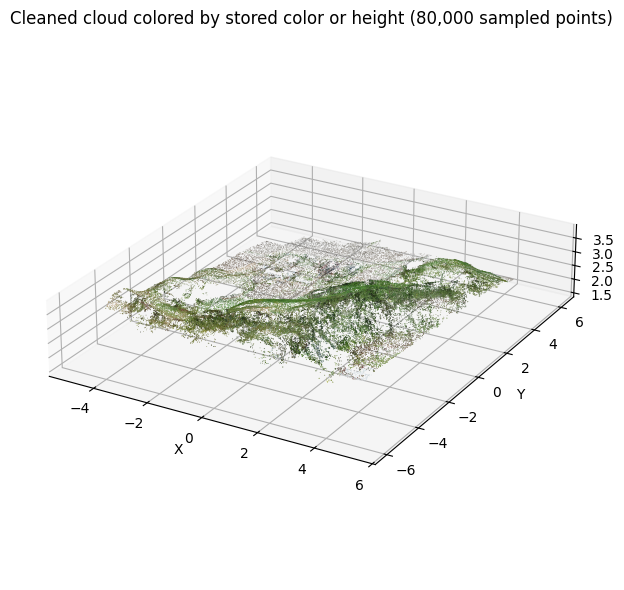

In [5]:
run_script("Analyze cleaned point cloud", "scripts/analyze_point_cloud.py", "--no-view")
show_cloud(CLEANED, "Cleaned cloud colored by stored color or height")

## 4. Ground Split: `segment_point_cloud.py`

This fits the dominant RANSAC plane as ground and writes separate ground/non-ground PLY files.


=== Segment ground and non-ground ===
c:\Users\jrwhite\AppData\Local\miniconda3\envs\drone-twin\python.exe C:\Users\jrwhite\Documents\Proj\DroneTwin\scripts\segment_point_cloud.py --no-view


Loaded 886,300 points
Median nearest-neighbor spacing: 0.009592
Plane model: -0.0340x + 0.0686y + 0.9971z + -2.5111 = 0
Ground/inlier points: 218,762
Non-ground/outlier points: 667,538
Wrote ground cloud to: C:\Users\jrwhite\Documents\Proj\DroneTwin\data\processed\dense\ground.ply
Wrote non-ground cloud to: C:\Users\jrwhite\Documents\Proj\DroneTwin\data\processed\dense\non_ground.ply

ok: data\processed\dense\ground.ply
ok: data\processed\dense\non_ground.ply


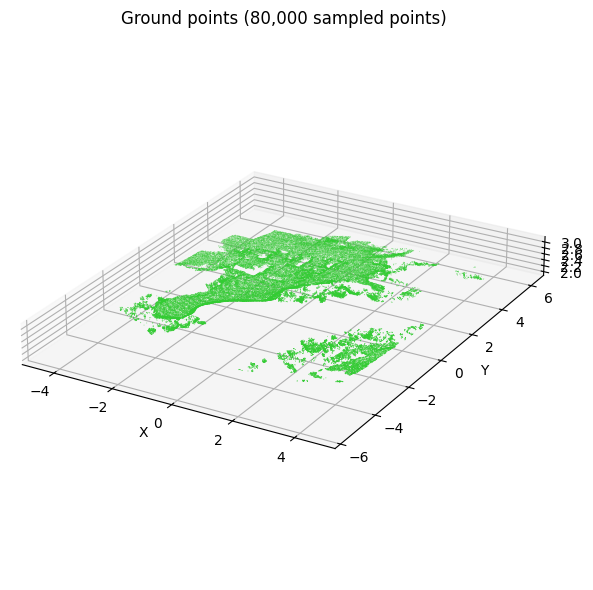

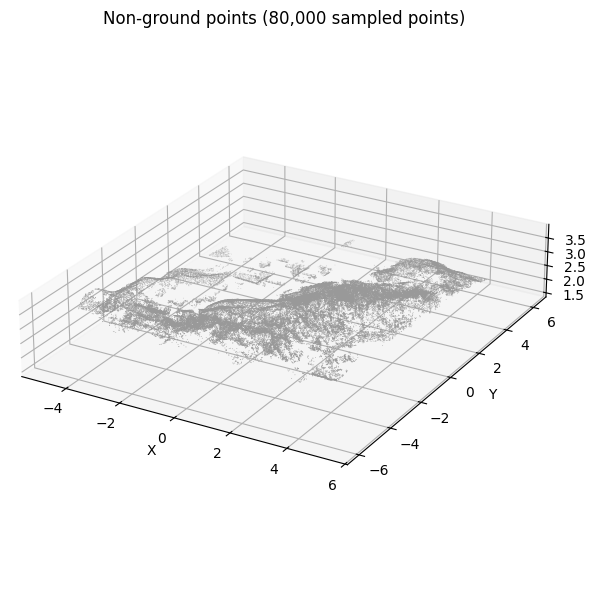

In [6]:
run_script("Segment ground and non-ground", "scripts/segment_point_cloud.py", "--no-view")
require_outputs(GROUND, NON_GROUND)
show_cloud(GROUND, "Ground points")
show_cloud(NON_GROUND, "Non-ground points")

## 5. Region Growing: `region_grow_non_ground.py`

This groups non-ground points into connected surface patches and writes the label sidecar used by semantic classification.


=== Grow non-ground surface regions ===
c:\Users\jrwhite\AppData\Local\miniconda3\envs\drone-twin\python.exe C:\Users\jrwhite\Documents\Proj\DroneTwin\scripts\region_grow_non_ground.py --proxy-output default


Region proxy voxel size: 0.079701 | 667,538 full points -> 29,051 proxy points
Detected 104 regions
Noise points: 32,436
  region    0:  523,357 points | extent=(10.291, 11.426, 1.568)
  region    9:   16,232 points | extent=(2.563, 1.697, 0.475)
  region    1:   14,436 points | extent=(1.377, 1.936, 0.522)
  region    7:    6,817 points | extent=(1.115, 2.127, 0.448)
  region   10:    6,647 points | extent=(1.225, 1.131, 0.308)
  region    5:    5,699 points | extent=(1.187, 1.399, 0.320)
  region   44:    3,776 points | extent=(0.744, 0.854, 0.350)
  region    8:    2,904 points | extent=(0.785, 0.904, 0.487)
  region   34:    2,879 points | extent=(0.793, 0.652, 0.566)
  region   24:    2,281 points | extent=(0.602, 0.632, 0.256)
  region    6:    2,124 points | extent=(0.548, 1.130, 0.458)
  region   11:    1,934 points | extent=(0.828, 1.200, 0.098)
Wrote full-resolution regions to: C:\Users\jrwhite\Documents\Proj\DroneTwin\data\processed\dense\non_ground_regions.ply
Wrote region 

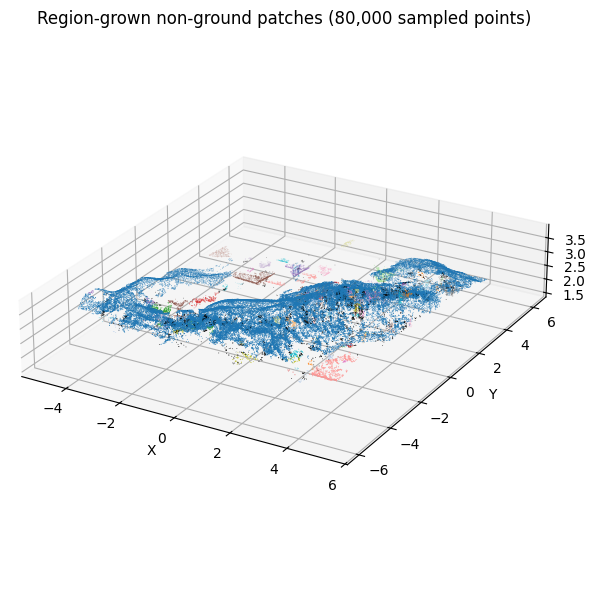

In [7]:
run_script(
    "Grow non-ground surface regions",
    "scripts/region_grow_non_ground.py",
    "--proxy-output",
    "default",
)
require_outputs(REGIONS, REGION_PROXY, REGION_LABELS)
show_cloud(REGIONS, "Region-grown non-ground patches")

## 6. Semantic Classes: `classify_regions.py`

This converts region features into coarse rule-based classes: ground, tree, water, building, other, and noise.


=== Classify regions ===
c:\Users\jrwhite\AppData\Local\miniconda3\envs\drone-twin\python.exe C:\Users\jrwhite\Documents\Proj\DroneTwin\scripts\classify_regions.py


Terrain ground inference: 1 seeds -> 60 regions
Absorbed 22,033 noise points into terrain ground
Classified non-ground points:
    ground: 608,176
      tree: 17,009
     water: 0
  building: 31,950
     other: 0
     noise: 10,403
Classified regions:
    ground: 76
      tree: 15
     water: 0
  building: 13
     other: 0
Wrote semantic scene to: C:\Users\jrwhite\Documents\Proj\DroneTwin\data\processed\dense\semantic_classes.ply
Wrote report to: C:\Users\jrwhite\Documents\Proj\DroneTwin\data\processed\dense\region_class_report.csv

ok: data\processed\dense\semantic_classes.ply
ok: data\processed\dense\non_ground_semantic_classes.ply
ok: data\processed\dense\region_class_report.csv
ok: data\processed\dense\semantic_class_legend.csv


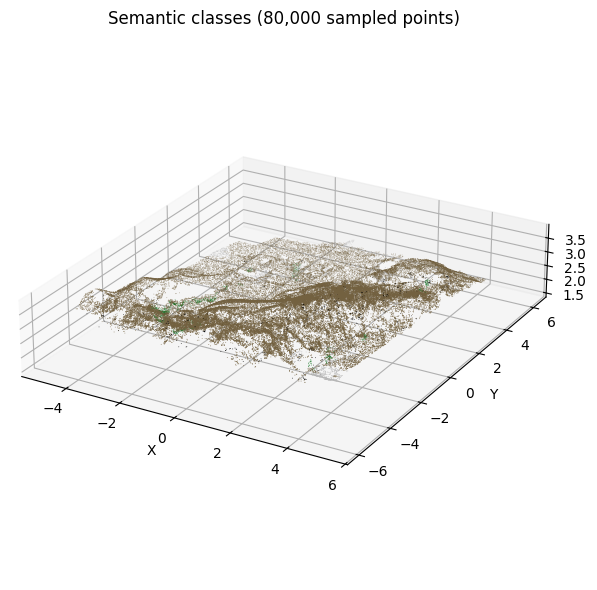

,class_name,region_count
0,ground,76
1,tree,15
2,building,13


,region_id,class_name,point_count,area,height_mean,height_std,extent_z,roughness,planarity,scattering,...,aspect,squareness,ground_score,tree_score,building_score,water_score,other_score,centroid_x,centroid_y,centroid_z
0,0,ground,20858,132.496323,0.519404,0.247963,1.528503,0.003793,0.294116,0.004947,...,1.427108,0.700718,0.937471,0.000000,0.000000,0.0,0.09,0.968211,-1.026503,3.143174
1,1,ground,587,3.728802,-0.206994,0.089967,0.508240,0.022325,0.206119,0.028185,...,1.709278,0.585042,0.418524,0.652827,0.522414,0.0,0.09,0.214939,1.151487,2.239086
2,2,tree,24,0.152455,-0.294544,0.109709,0.427022,0.060390,0.265413,0.086915,...,1.402964,0.712777,0.250000,1.294926,0.370179,0.0,0.09,3.110478,-3.656645,2.580917
3,3,ground,23,0.146103,0.689564,0.068503,0.219506,0.077211,0.470080,0.134235,...,1.749268,0.571668,0.250000,1.056270,0.417042,0.0,0.09,2.624979,-0.043208,3.302772
4,4,ground,20,0.127046,0.631808,0.090691,0.303873,0.025590,0.469793,0.039640,...,2.604357,0.383972,0.289001,0.496021,0.345503,0.0,0.09,-0.019644,-4.527851,3.463034
5,5,building,276,1.753235,-0.195506,0.067926,0.292922,0.023821,0.445693,0.036160,...,1.049895,0.952476,0.325492,0.361343,0.633922,0.0,0.09,1.278379,4.536905,2.054039
6,6,tree,126,0.800390,-0.225048,0.088473,0.407371,0.026900,0.098118,0.031219,...,3.771277,0.265162,0.330710,0.577473,0.282118,0.0,0.09,-2.668999,-0.586715,2.242066
7,7,building,354,2.248715,-0.178164,0.086980,0.445404,0.016426,0.158812,0.019681,...,1.876665,0.532860,0.467826,0.507929,0.543084,0.0,0.09,3.881208,-3.727137,2.728809
8,8,building,154,0.978255,-0.163211,0.057328,0.450827,0.025526,0.466616,0.039451,...,1.140808,0.876572,0.290710,0.552940,0.631413,0.0,0.09,-1.396403,3.331638,2.077997
9,9,ground,885,5.621788,-0.207808,0.085888,0.458755,0.014129,0.409158,0.020489,...,1.480389,0.675498,0.582250,0.520522,0.608927,0.0,0.09,1.584148,2.512968,2.191372


In [8]:
classify_args = ["--view"] if VIEW_SEMANTIC_CLASSES else []
run_script("Classify regions", "scripts/classify_regions.py", *classify_args)
require_outputs(SEMANTIC, NON_GROUND_SEMANTIC, REPORT, LEGEND)
show_cloud(SEMANTIC, "Semantic classes")
show_class_report(REPORT)

## Results Summary

This section turns the generated artifacts into reviewable evidence: file sizes, point counts, and semantic class counts.

In [9]:
def ply_vertex_count(path: Path) -> int | None:
    """Read the PLY header to get point count without loading the full cloud."""
    with path.open("rb") as handle:
        for raw_line in handle:
            line = raw_line.decode("utf-8", errors="ignore").strip()
            if line.startswith("element vertex"):
                return int(line.split()[-1])
            if line == "end_header":
                return None
    return None


artifact_rows = []
for name, path in [
    ("raw fused cloud", RAW_FUSED),
    ("cleaned cloud", CLEANED),
    ("ground cloud", GROUND),
    ("non-ground cloud", NON_GROUND),
    ("region-grown non-ground", REGIONS),
    ("semantic scene", SEMANTIC),
    ("semantic non-ground", NON_GROUND_SEMANTIC),
]:
    artifact_rows.append(
        {
            "artifact": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "size_mb": round(path.stat().st_size / (1024 * 1024), 2),
            "points": ply_vertex_count(path),
        }
    )

artifact_summary = pd.DataFrame(artifact_rows)
display(artifact_summary)

report = pd.read_csv(REPORT)
class_summary = (
    report.groupby("class_name", as_index=False)
    .agg(region_count=("region_id", "count"), total_proxy_points=("point_count", "sum"))
    .sort_values("region_count", ascending=False)
)
display(class_summary)

print(
    "Key takeaway: the pipeline reduces a very large COLMAP reconstruction "
    "into inspectable segmented artifacts and explainable class reports."
)

,artifact,path,size_mb,points
0,raw fused cloud,data\processed\dense\fused-keep-more.ply,395.97,15377970
1,cleaned cloud,data\processed\dense\fused-keep-more-cleaned.ply,43.11,886300
2,ground cloud,data\processed\dense\ground.ply,10.64,218762
3,non-ground cloud,data\processed\dense\non_ground.ply,32.47,667538
4,region-grown non-ground,data\processed\dense\non_ground_regions.ply,32.47,667538
5,semantic scene,data\processed\dense\semantic_classes.ply,43.11,886300
6,semantic non-ground,data\processed\dense\non_ground_semantic_class...,32.47,667538


,class_name,region_count,total_proxy_points
1,ground,76,24115
2,tree,15,964
0,building,13,1609


Key takeaway: the pipeline reduces a very large COLMAP reconstruction into inspectable segmented artifacts and explainable class reports.


## Technical Takeaways

- The raw COLMAP fusion is large and noisy; the cleanup stage makes it practical to inspect and segment.
- The ground split converts one dense cloud into terrain and elevated structure, which makes later classification easier to reason about.
- Region growing creates object/structure candidates before semantic labeling, so classification is based on surfaces rather than individual noisy points.
- The semantic stage is intentionally rule-based and transparent; the CSV report shows why each region was labeled instead of hiding the decision inside a black-box model.